# Spiking Neural Network for Tactile Object Recognition on DYNAP-SE

## Overview
This notebook demonstrates training and inference of a spiking neural network (SNN) for tactile object classification using the DYNAP-SE neuromorphic processor with computer-in-the-loop gradient descent training. The network processes spike-encoded tactile data and learns the readout weights via backpropagation.

## Workflow
1. **Data Loading** – Load preprocessed spike-encoded tactile data
2. **Hardware Setup** – Connect to and configure the DYNAP-SE board via Samna
3. **Network Architecture** – Build a 3-layer FC network:
   - Input (spike generators, core 0) → Sparse fixed synapses (0.4 prob) → Hidden (if too large split between cores 1 and 2)
   - Hidden → Plastic synapses (via gradient descent) → Output (readout, core 3)
4. **Parameter Configuration** – Set neuron and synapse analog parameters
5. **Monitoring Setup** – Configure event listeners for hidden and output layers
6. **Learning** – Run computer-in-the-loop training using gradient descent on the readout weights
7. **Evaluation** – Compute accuracy and visualize firing rates across layers

1. i parametri sembrano non influenzare il firing rate dell'hidden layer \
2. dopo aver aggiornato i pesi, devo reinizializzare la configurazione? questo non resetta i parametri?
3. il metodo standard per settare i parametri non funziona?
4. ogni quanto aggiornare i pesi?
5. mandare i sample shuffled o in sequenza classe per classe?

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt
import samna
import samna.dynapse1 as dyn1 # type: ignore
from utils import load_and_prepare_data, enforce_exact_fanin_budget, build_fpga_stimulus_for_sample
import dynapse1utils as ut
from dynapse1constants import NEURONS_PER_CORE, MAX_FPGA_LEN
from netgen import NetworkGenerator, NeuronGroup, Synapses, add_synapses, remove_synapses
from stdp_utils import floatW2intW

## Load data

In [2]:
preprocess_params = {
    "method": "fps",
    "n": 16,
    "num_frames": 25,
    "threshold": 0.01,
    "channels": 1,
    "down_spike": 1.0,
    "encoding": "spike",
    "session_id": [0, 1],
}

X_train, y_train, X_test, y_test, num_inputs, num_classes, kept_class_names = load_and_prepare_data(
    preprocess_params, 
    selected_classes=['lotion', 'safety_glasses']
)

Loading: preprocessed_data/spike_data_method_fps_n_16_num_frames_25_threshold_0.01_channels_1_down_spike_1.0_encoding_spike_session_id_0_1.pkl
Loaded: preprocessed_data/spike_data_method_fps_n_16_num_frames_25_threshold_0.01_channels_1_down_spike_1.0_encoding_spike_session_id_0_1.pkl | params: {'method': 'fps', 'n': 16, 'num_frames': 25, 'threshold': 0.01, 'session_id': [0, 1], 'channels': 1, 'down_spike': 1.0, 'encoding': 'spike'}
Raw shape: 1632 samples, T=25, inputs=16
Kept 2 classes: ['lotion', 'safety_glasses']
Class counts: [96 96]
Train: 152, Test: 40


## CONNECT TO DYNAP-SE BOARD

In [4]:
model, gui_process = ut.open_dynapse1(gui=False)

ERROR: Address already in use, please re-run open_device()!
[0]:  Bus 20 Device 1 Dynapse1DevKit serial_number 00000014
0 Dynapse1Wrapper created! libcaer init...
Selected device: 00000014
Sender port: tcp://0.0.0.0:51067
Receiver port: tcp://0.0.0.0:51068
Opened device name: Dynapse1DevKit
SamnaNode ID: 1
PythonNode ID: 2
Clearing chip 0... DONE.
Clearing chip 1... DONE.
Clearing chip 2... DONE.
Clearing chip 3... DONE.


In [5]:
net_gen = NetworkGenerator()

# Calculate hidden layer distribution across cores
num_hidden = 3 * num_inputs
max_per_core = NEURONS_PER_CORE - 1
hidden_size_1 = min(num_hidden, max_per_core)
hidden_size_2 = max(0, num_hidden - hidden_size_1)

print(f"Network: Input={num_inputs} → Hidden1={hidden_size_1} + Hidden2={hidden_size_2} → Output={num_classes}")

# Define neuron populations
input_group = NeuronGroup(chip_id=0, core_id=0, neuron_ids=list(range(num_inputs)), is_spike_gen=True)
hidden_group_1 = NeuronGroup(chip_id=0, core_id=1, neuron_ids=list(range(1, 1 + hidden_size_1)), is_spike_gen=False)
hidden_group_2 = NeuronGroup(chip_id=0, core_id=2, neuron_ids=list(range(1, 1 + hidden_size_2)), is_spike_gen=False) if hidden_size_2 > 0 else None
output_group = NeuronGroup(chip_id=0, core_id=3, neuron_ids=list(range(1, 1 + num_classes)), is_spike_gen=False)

# Build input → hidden synapses with sparse connections (0.4 probability)
INPUT_HIDDEN_SPARSITY = 0.4

# Create sparse weight matrix for input -> hidden_1
weight_matrix_1 = np.random.binomial(1, INPUT_HIDDEN_SPARSITY, size=(num_inputs, hidden_size_1)).astype(float)
input_hidden_syn_1 = Synapses(input_group, hidden_group_1, dyn1.Dynapse1SynType.AMPA, weight_matrix=weight_matrix_1)

input_hidden_syn_2 = None
if hidden_group_2:
    weight_matrix_2 = np.random.binomial(1, INPUT_HIDDEN_SPARSITY, size=(num_inputs, hidden_size_2)).astype(float)
    input_hidden_syn_2 = Synapses(input_group, hidden_group_2, dyn1.Dynapse1SynType.AMPA, weight_matrix=weight_matrix_2)

# Build hidden → output synapses (plastic readout for gradient descent)
PLASTIC_BUDGET = 64
num_hidden_total = len(hidden_group_1.neurons) + (len(hidden_group_2.neurons) if hidden_group_2 else 0)
w_plast = np.ones((num_hidden_total, num_classes), dtype=float)

int_w_plast = floatW2intW(w_plast, max_pre_count=PLASTIC_BUDGET, unit=0.25)
int_w_plast = enforce_exact_fanin_budget(int_w_plast, PLASTIC_BUDGET, max_weight=4, seed=None)

split_idx = len(hidden_group_1.neurons)
int_w_plast_1 = int_w_plast[:split_idx, :]
int_w_plast_2 = int_w_plast[split_idx:, :]

hidden_output_syn_1 = Synapses(hidden_group_1, output_group, dyn1.Dynapse1SynType.AMPA, weight_matrix=int_w_plast_1)
hidden_output_syn_2 = Synapses(hidden_group_2, output_group, dyn1.Dynapse1SynType.AMPA, weight_matrix=int_w_plast_2) if hidden_group_2 else None

# Add synapses to network
connectivity = {}
connectivity['input_hidden_1'] = input_hidden_syn_1
if input_hidden_syn_2:
    connectivity['input_hidden_2'] = input_hidden_syn_2
connectivity['hidden_output_1'] = hidden_output_syn_1
if hidden_output_syn_2:
    connectivity['hidden_output_2'] = hidden_output_syn_2

for conn_name in connectivity:
    print(conn_name)
    add_synapses(net_gen, connectivity[conn_name])

print(net_gen.network)

config = net_gen.make_dynapse1_configuration(validation=True)
model.apply_configuration(config)

Network: Input=16 → Hidden1=48 + Hidden2=0 → Output=2
input_hidden_1
hidden_output_1
Post neuron (ChipId,coreId,neuronId): incoming connections [(preNeuron,synapseType), ...]
C0c1n2: [('C0c0s0', 'AMPA'), ('C0c0s1', 'AMPA'), ('C0c0s13', 'AMPA'), ('C0c0s15', 'AMPA')]
C0c1n11: [('C0c0s0', 'AMPA'), ('C0c0s3', 'AMPA'), ('C0c0s5', 'AMPA'), ('C0c0s6', 'AMPA'), ('C0c0s7', 'AMPA'), ('C0c0s8', 'AMPA'), ('C0c0s10', 'AMPA'), ('C0c0s11', 'AMPA'), ('C0c0s12', 'AMPA'), ('C0c0s13', 'AMPA')]
C0c1n14: [('C0c0s0', 'AMPA'), ('C0c0s3', 'AMPA'), ('C0c0s8', 'AMPA'), ('C0c0s10', 'AMPA'), ('C0c0s11', 'AMPA'), ('C0c0s15', 'AMPA')]
C0c1n19: [('C0c0s0', 'AMPA'), ('C0c0s2', 'AMPA'), ('C0c0s4', 'AMPA'), ('C0c0s6', 'AMPA'), ('C0c0s7', 'AMPA'), ('C0c0s8', 'AMPA'), ('C0c0s11', 'AMPA'), ('C0c0s12', 'AMPA'), ('C0c0s13', 'AMPA'), ('C0c0s15', 'AMPA')]
C0c1n22: [('C0c0s0', 'AMPA'), ('C0c0s2', 'AMPA'), ('C0c0s5', 'AMPA'), ('C0c0s6', 'AMPA'), ('C0c0s7', 'AMPA'), ('C0c0s9', 'AMPA'), ('C0c0s10', 'AMPA'), ('C0c0s11', 'AMPA'), (

In [6]:
fpga_spike_gen = model.get_fpga_spike_gen()
FRAME_DURATION_MS = 10

# Monitor input layer spikes (spike generators)
input_neuron_ids = list(input_group.tuple_neuron_ids)
in_graph, in_filter, in_sink = ut.create_neuron_select_graph(model, input_neuron_ids)
in_graph.start()
in_sink.get_events()

# Monitor output layer spikes
output_neuron_ids = output_group.tuple_neuron_ids
out_graph, out_filter, out_sink = ut.create_neuron_select_graph(model, output_neuron_ids)
out_graph.start()
out_sink.get_events()

# Monitor hidden layer spikes
hidden_neuron_ids = list(hidden_group_1.tuple_neuron_ids)
if hidden_group_2:
    hidden_neuron_ids += list(hidden_group_2.tuple_neuron_ids)

hidden_graph, hidden_filter, hidden_sink = ut.create_neuron_select_graph(model, hidden_neuron_ids)
hidden_graph.start()
hidden_sink.get_events()

print(f"Monitoring: {len(input_neuron_ids)} input + {len(hidden_neuron_ids)} hidden + {len(output_neuron_ids)} output neurons")
print(f"Setup complete. Ready for gradient descent training.")

Monitoring: 16 input + 48 hidden + 2 output neurons
Setup complete. Ready for gradient descent training.


## CONFIGURE NEURON & SYNAPSE PARAMETERS

In [7]:
def set_neuron_synapse_params(cfg):
    """Set analog parameters for all cores."""
    param_groups = [cfg.chips[0].cores[i].parameter_group for i in range(4)]
    
    for pg in param_groups:
        # Neuron thresholds and time constants
        pg.param_map["IF_THR_N"].coarse_value, pg.param_map["IF_THR_N"].fine_value = 5, 80
        pg.param_map["IF_RFR_N"].coarse_value, pg.param_map["IF_RFR_N"].fine_value = 4, 128
        pg.param_map["IF_TAU1_N"].coarse_value, pg.param_map["IF_TAU1_N"].fine_value = 4, 80
        pg.param_map["IF_TAU2_N"].coarse_value, pg.param_map["IF_TAU2_N"].fine_value = 7, 255
        pg.param_map["IF_DC_P"].coarse_value, pg.param_map["IF_DC_P"].fine_value = 0, 0
        
        # AMPA synapses
        pg.param_map["NPDPIE_TAU_F_P"].coarse_value, pg.param_map["NPDPIE_TAU_F_P"].fine_value = 4, 80
        pg.param_map["NPDPIE_THR_F_P"].coarse_value, pg.param_map["NPDPIE_THR_F_P"].fine_value = 4, 80
        pg.param_map["PS_WEIGHT_EXC_F_N"].coarse_value, pg.param_map["PS_WEIGHT_EXC_F_N"].fine_value = 6, 80
        
        # NMDA synapses
        pg.param_map["NPDPIE_TAU_S_P"].coarse_value, pg.param_map["NPDPIE_TAU_S_P"].fine_value = 4, 80
        pg.param_map["NPDPIE_THR_S_P"].coarse_value, pg.param_map["NPDPIE_THR_S_P"].fine_value = 4, 80
        pg.param_map["PS_WEIGHT_EXC_S_N"].coarse_value, pg.param_map["PS_WEIGHT_EXC_S_N"].fine_value = 7, 80
        pg.param_map["IF_NMDA_N"].coarse_value, pg.param_map["IF_NMDA_N"].fine_value = 0, 0
        
        # GABA synapses (inhibitory)
        pg.param_map["NPDPII_TAU_F_P"].coarse_value, pg.param_map["NPDPII_TAU_F_P"].fine_value = 4, 80
        pg.param_map["NPDPII_THR_F_P"].coarse_value, pg.param_map["NPDPII_THR_F_P"].fine_value = 4, 80
        pg.param_map["PS_WEIGHT_INH_F_N"].coarse_value, pg.param_map["PS_WEIGHT_INH_F_N"].fine_value = 0, 0
        pg.param_map["NPDPII_TAU_S_P"].coarse_value, pg.param_map["NPDPII_TAU_S_P"].fine_value = 4, 80
        pg.param_map["NPDPII_THR_S_P"].coarse_value, pg.param_map["NPDPII_THR_S_P"].fine_value = 4, 80
        pg.param_map["PS_WEIGHT_INH_S_N"].coarse_value, pg.param_map["PS_WEIGHT_INH_S_N"].fine_value = 0, 0
        
        # Adaptation & misc
        pg.param_map["IF_AHTAU_N"].coarse_value, pg.param_map["IF_AHTAU_N"].fine_value = 4, 80
        pg.param_map["IF_AHTHR_N"].coarse_value, pg.param_map["IF_AHTHR_N"].fine_value = 0, 0
        pg.param_map["IF_AHW_P"].coarse_value, pg.param_map["IF_AHW_P"].fine_value = 0, 0
        pg.param_map["IF_CASC_N"].coarse_value, pg.param_map["IF_CASC_N"].fine_value = 0, 0
        pg.param_map["PULSE_PWLK_P"].coarse_value, pg.param_map["PULSE_PWLK_P"].fine_value = 4, 106
        pg.param_map["R2R_P"].coarse_value, pg.param_map["R2R_P"].fine_value = 3, 85
        pg.param_map["IF_BUF_P"].coarse_value, pg.param_map["IF_BUF_P"].fine_value = 3, 80

set_neuron_synapse_params(config)

## INFERENCE & EVALUATION

In [8]:
def infer_one(sample_tensor, slack_s=0.05):
    """Run one sample, return prediction, output spike counts, and hidden spike counts."""
    out_sink.get_events()
    hidden_sink.get_events()
    
    spike_times, indices, target_chips = build_fpga_stimulus_for_sample(
        sample_tensor, base_spikegen_id=0, chip_id=0, frame_duration_ms=FRAME_DURATION_MS
    )
    duration_s = (sample_tensor.shape[0] * FRAME_DURATION_MS) / 1000.0
    
    ut.set_fpga_spike_gen(fpga_spike_gen, spike_times, indices, target_chips, isi_base=900, repeat_mode=False)
    fpga_spike_gen.start()
    time.sleep(duration_s + slack_s)
    fpga_spike_gen.stop()
    
    # Collect output spikes
    out_events = out_sink.get_events()
    out_counts = np.zeros(len(output_neuron_ids), dtype=int)
    
    if out_events:
        id_to_idx = {nid: i for i, nid in enumerate(output_neuron_ids)}
        for ev in out_events:
            nid = (ev.chip_id, ev.core_id, ev.neuron_id)
            if nid in id_to_idx:
                out_counts[id_to_idx[nid]] += 1
    
    # Collect hidden layer spikes
    hidden_events = hidden_sink.get_events()
    hidden_counts = np.zeros(len(hidden_neuron_ids), dtype=int)
    
    if hidden_events:
        hid_map = {nid: j for j, nid in enumerate(hidden_neuron_ids)}
        for ev in hidden_events:
            nid = (ev.chip_id, ev.core_id, ev.neuron_id)
            if nid in hid_map:
                hidden_counts[hid_map[nid]] += 1
    
    pred = np.argmax(out_counts)
    return pred, out_counts, hidden_counts, duration_s

def evaluate_accuracy(X, y):
    """Evaluate network accuracy and collect firing rates across all layers."""
    n = len(X)
    cm = np.zeros((num_classes, num_classes), dtype=int)
    correct = 0
    
    output_spikes = np.zeros(len(output_neuron_ids), dtype=np.float64)
    hidden_spikes = np.zeros(len(hidden_neuron_ids), dtype=np.float64)
    input_spikes = np.zeros(num_inputs, dtype=np.float64)
    total_duration = 0.0
    
    for i in range(n):
        pred, out_counts, hidden_counts, duration = infer_one(X[i])
        true = int(y[i])
        cm[true, pred] += 1                         # count every prediction, row sums = samples per class
        correct += (pred == true)
        
        output_spikes += out_counts
        hidden_spikes += hidden_counts
        input_spikes += np.sum(X[i], axis=0)
        total_duration += duration
        
        if (i + 1) % 50 == 0:
            print(f"Eval: {i+1}/{n}")
    
    acc = correct / n if n > 0 else 0.0
    input_rates = input_spikes / total_duration if total_duration > 0 else input_spikes
    hidden_rates = hidden_spikes / total_duration if total_duration > 0 else hidden_spikes
    output_rates = output_spikes / total_duration if total_duration > 0 else output_spikes
    
    return acc, cm, input_rates, hidden_rates, output_rates

## TRAINING WITH GRADIENT DESCENT

In [24]:
def compute_gradient_update(hidden_counts, output_counts, true_label, learning_rate=0.01):
    """
    Compute weight gradient for readout layer using gradient descent.
    Uses spike counts as features: dW = -learning_rate * (pred_output - true_output) * hidden_counts
    """
    # Create target: one-hot encoding of true label
    target = np.zeros(num_classes, dtype=float)
    target[true_label] = 1.0
    
    # Normalize output counts to create soft prediction
    output_normed = output_counts.astype(float) / (np.sum(output_counts) + 1e-8)
    
    # Compute error: (prediction - target)
    error = output_normed - target  # shape: (num_classes,)
    
    # Compute gradient: error_per_class * hidden_activations
    # dW shape: (num_hidden, num_classes)
    gradients = np.outer(hidden_counts, error)  # outer product
    
    return gradients


NUM_EPOCHS = 3
LEARNING_RATE = 0.01
SHUFFLE_SEED = 42
best_acc = -1.0
best_weights = None

# Initialize weight matrix in float for accumulation
w_plast_float = np.ones((num_hidden_total, num_classes), dtype=float)

for epoch in range(NUM_EPOCHS):
    print(f"\n===== Epoch {epoch+1}/{NUM_EPOCHS} =====")
    
    perm = np.arange(len(X_train))
    np.random.seed(SHUFFLE_SEED + epoch)
    np.random.shuffle(perm)
    
    for step, idx in enumerate(perm):
        x, y = X_train[idx], int(y_train[idx])
        
        # Forward pass: run sample through chip
        pred, out_counts, hidden_counts, duration_s = infer_one(x)
        
        # Compute gradient and update weights
        gradients = compute_gradient_update(hidden_counts, out_counts, y, LEARNING_RATE)
        w_plast_float -= LEARNING_RATE * gradients  # gradient descent step
        
        # Clip weights to valid range
        w_plast_float = np.clip(w_plast_float, 0, 4)
        
        # Update hardware weights every sample
        int_w = floatW2intW(w_plast_float, max_pre_count=PLASTIC_BUDGET, unit=0.25)
        int_w = enforce_exact_fanin_budget(int_w, PLASTIC_BUDGET, max_weight=4, seed=epoch * 10000 + step)
        
        # Update chip configuration
        remove_synapses(net_gen, hidden_output_syn_1)
        if hidden_output_syn_2:
            remove_synapses(net_gen, hidden_output_syn_2)
        
        hidden_output_syn_1 = Synapses(hidden_group_1, output_group, dyn1.Dynapse1SynType.AMPA, 
                                       weight_matrix=int_w[:split_idx, :])
        hidden_output_syn_2 = Synapses(hidden_group_2, output_group, dyn1.Dynapse1SynType.AMPA,
                                       weight_matrix=int_w[split_idx:, :]) if hidden_group_2 else None
        
        add_synapses(net_gen, hidden_output_syn_1)
        if hidden_output_syn_2:
            add_synapses(net_gen, hidden_output_syn_2)
        
        cfg = net_gen.make_dynapse1_configuration(validation=False)
        model.apply_configuration(cfg)
        time.sleep(0.01)  # brief pause for hardware update
        
        if (step + 1) % 100 == 0:
            print(f"Train: {step+1}/{len(X_train)} (pred={pred}, true={y})")
    
    # Evaluate on test set
    test_acc, test_cm, input_rates, hidden_rates, output_rates = evaluate_accuracy(X_test, y_test)
    print(f"Test accuracy: {test_acc*100:.2f}%")
    print("Confusion matrix:\n", test_cm)
    
    if test_acc > best_acc:
        best_acc = test_acc
        best_weights = int_w.copy()
        print(f"New best: {best_acc*100:.2f}%")

print(f"\nTraining complete. Best accuracy: {best_acc*100:.2f}%")


===== Epoch 1/3 =====
VariableIsiMode already 1
RepeatMode already 0
New configuration applied to DYNAP-SE1!
VariableIsiMode already 1
RepeatMode already 0
New configuration applied to DYNAP-SE1!
VariableIsiMode already 1
RepeatMode already 0
New configuration applied to DYNAP-SE1!
VariableIsiMode already 1
RepeatMode already 0
New configuration applied to DYNAP-SE1!
VariableIsiMode already 1
RepeatMode already 0


KeyboardInterrupt: 

## FINAL EVALUATION & VISUALIZATION

RepeatMode already 0
VariableIsiMode already 1
RepeatMode already 0
VariableIsiMode already 1
RepeatMode already 0
VariableIsiMode already 1
RepeatMode already 0
VariableIsiMode already 1
RepeatMode already 0
VariableIsiMode already 1
RepeatMode already 0
VariableIsiMode already 1
RepeatMode already 0
VariableIsiMode already 1
RepeatMode already 0
VariableIsiMode already 1
RepeatMode already 0
VariableIsiMode already 1
RepeatMode already 0
VariableIsiMode already 1
RepeatMode already 0
VariableIsiMode already 1
RepeatMode already 0
VariableIsiMode already 1
RepeatMode already 0
VariableIsiMode already 1
RepeatMode already 0
VariableIsiMode already 1
RepeatMode already 0
VariableIsiMode already 1
RepeatMode already 0
VariableIsiMode already 1
RepeatMode already 0
VariableIsiMode already 1
RepeatMode already 0
VariableIsiMode already 1
RepeatMode already 0
VariableIsiMode already 1
RepeatMode already 0
VariableIsiMode already 1
RepeatMode already 0
VariableIsiMode already 1
RepeatMode al

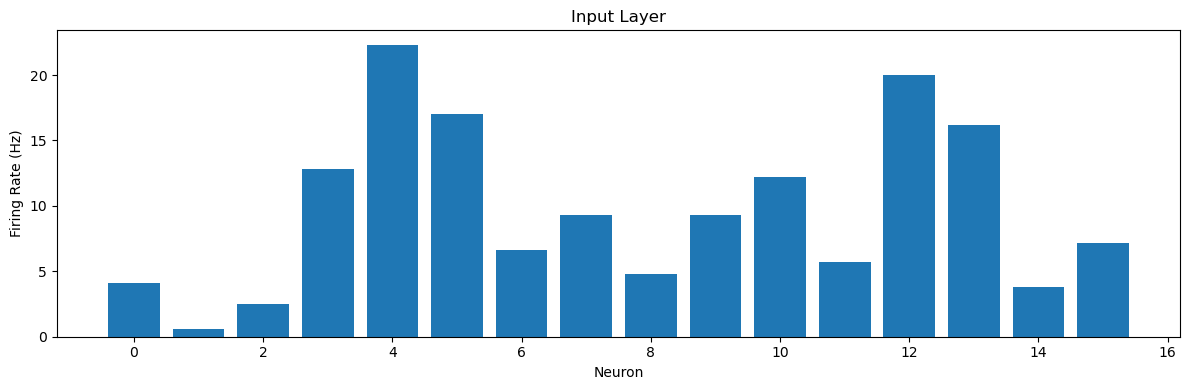

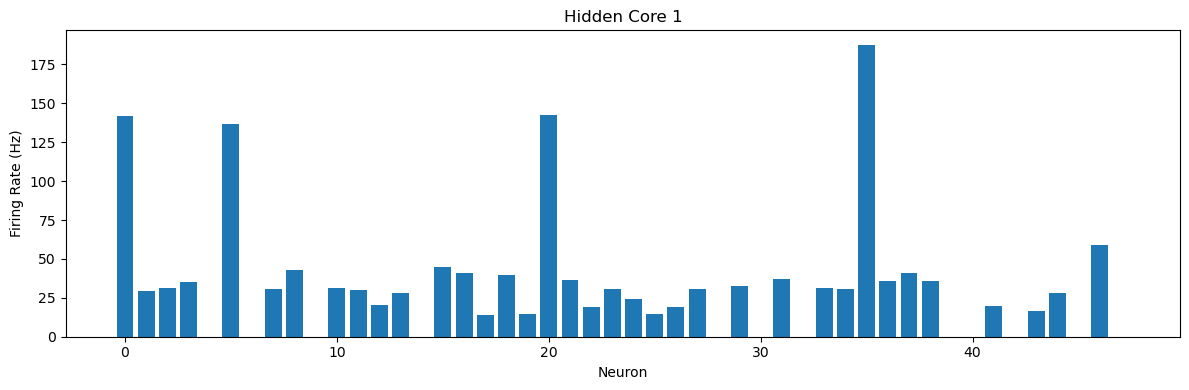

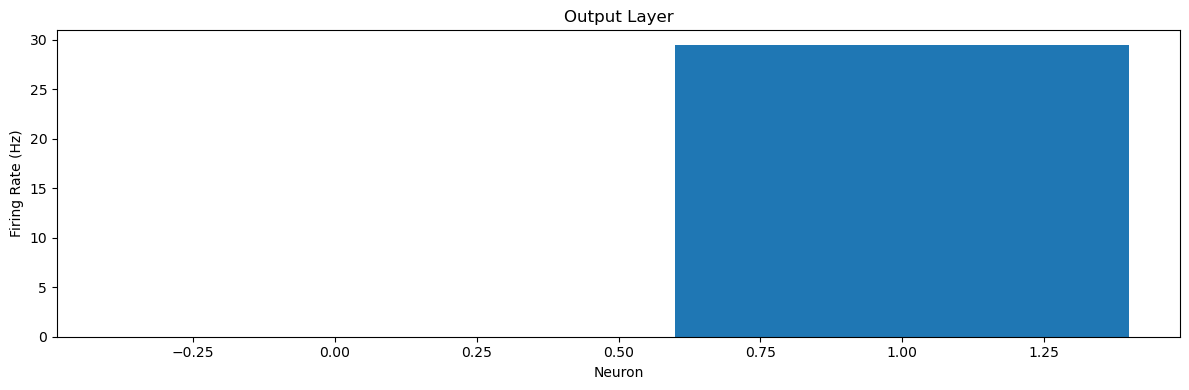

In [9]:
test_acc, test_cm, input_rates, hidden_rates, output_rates = evaluate_accuracy(X_test, y_test)
print("Confusion matrix:\n", test_cm)

def plot_rates(rates, title, neuron_range):
    plt.figure(figsize=(12, 4))
    plt.bar(range(len(rates)), rates)
    plt.xlabel('Neuron')
    plt.ylabel('Firing Rate (Hz)')
    plt.title(title)
    plt.tight_layout()
    plt.show()

plot_rates(input_rates, 'Input Layer', range(num_inputs))
plot_rates(hidden_rates[:split_idx], 'Hidden Core 1', range(split_idx))
if hidden_group_2:
    plot_rates(hidden_rates[split_idx:], 'Hidden Core 2', range(len(hidden_rates) - split_idx))
plot_rates(output_rates, 'Output Layer', range(num_classes))

VariableIsiMode already 1
RepeatMode already 0
VariableIsiMode already 1
RepeatMode already 0
VariableIsiMode already 1
RepeatMode already 0
VariableIsiMode already 1
RepeatMode already 0
VariableIsiMode already 1
RepeatMode already 0
VariableIsiMode already 1
RepeatMode already 0
VariableIsiMode already 1
RepeatMode already 0
VariableIsiMode already 1
RepeatMode already 0
VariableIsiMode already 1
RepeatMode already 0
VariableIsiMode already 1
RepeatMode already 0


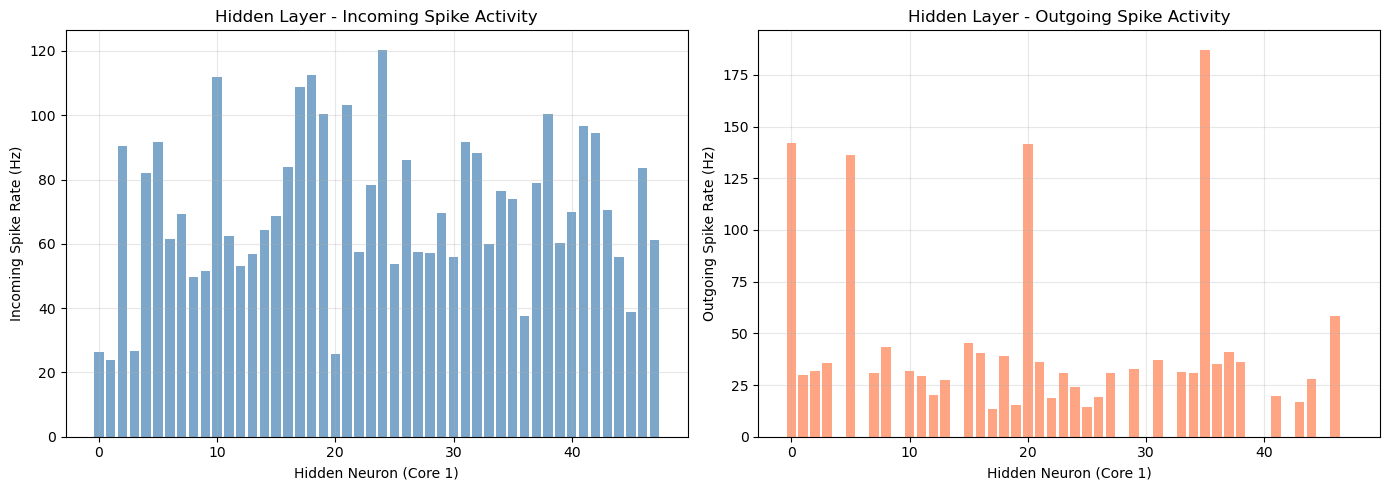

Incoming spikes - Mean: 70.84 Hz, Max: 120.40 Hz
Outgoing spikes - Mean: 32.96 Hz, Max: 187.20 Hz


In [10]:
## HIDDEN LAYER SPIKE ACTIVITY ANALYSIS

# Run evaluation to collect spike activity
test_acc, test_cm, input_rates, hidden_rates, output_rates = evaluate_accuracy(X_test[:10], y_test[:10])

# Compute incoming spikes to hidden neurons (based on input->hidden connectivity)
# incoming_spikes = input_spikes @ weight_matrix_incoming
incoming_spikes_h1 = input_rates @ weight_matrix_1

# Plot incoming vs outgoing spikes for hidden layer
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Incoming spikes
axes[0].bar(range(len(incoming_spikes_h1)), incoming_spikes_h1, color='steelblue', alpha=0.7)
axes[0].set_xlabel('Hidden Neuron (Core 1)')
axes[0].set_ylabel('Incoming Spike Rate (Hz)')
axes[0].set_title('Hidden Layer - Incoming Spike Activity')
axes[0].grid(True, alpha=0.3)

# Outgoing spikes
axes[1].bar(range(len(hidden_rates[:split_idx])), hidden_rates[:split_idx], color='coral', alpha=0.7)
axes[1].set_xlabel('Hidden Neuron (Core 1)')
axes[1].set_ylabel('Outgoing Spike Rate (Hz)')
axes[1].set_title('Hidden Layer - Outgoing Spike Activity')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Summary statistics
print(f"Incoming spikes - Mean: {np.mean(incoming_spikes_h1):.2f} Hz, Max: {np.max(incoming_spikes_h1):.2f} Hz")
print(f"Outgoing spikes - Mean: {np.mean(hidden_rates[:split_idx]):.2f} Hz, Max: {np.max(hidden_rates[:split_idx]):.2f} Hz")

## CLEANUP

In [47]:
ut.close_dynapse1(model, gui_process)